Streaming output truncated to the last 5000 lines.
  inflating: FER2013/train/sad/Training_65329617.jpg  
  inflating: FER2013/train/sad/Training_65338712.jpg  
  inflating: FER2013/train/sad/Training_65338797.jpg  
  inflating: FER2013/train/sad/Training_65387162.jpg  
  inflating: FER2013/train/sad/Training_65404494.jpg  
  inflating: FER2013/train/sad/Training_65426218.jpg  
  inflating: FER2013/train/sad/Training_65430136.jpg  
  inflating: FER2013/train/sad/Training_65437377.jpg  
  inflating: FER2013/train/sad/Training_6545735.jpg  
  inflating: FER2013/train/sad/Training_65463385.jpg  
  inflating: FER2013/train/sad/Training_65473985.jpg  
  inflating: FER2013/train/sad/Training_65502829.jpg  
  inflating: FER2013/train/sad/Training_65505359.jpg  
  inflating: FER2013/train/sad/Training_65508578.jpg  
  inflating: FER2013/train/sad/Training_65516023.jpg  
  inflating: FER2013/train/sad/Training_65524027.jpg  
  inflating: FER2013/train/sad/Training_65526454.jpg  
  inflating: FE

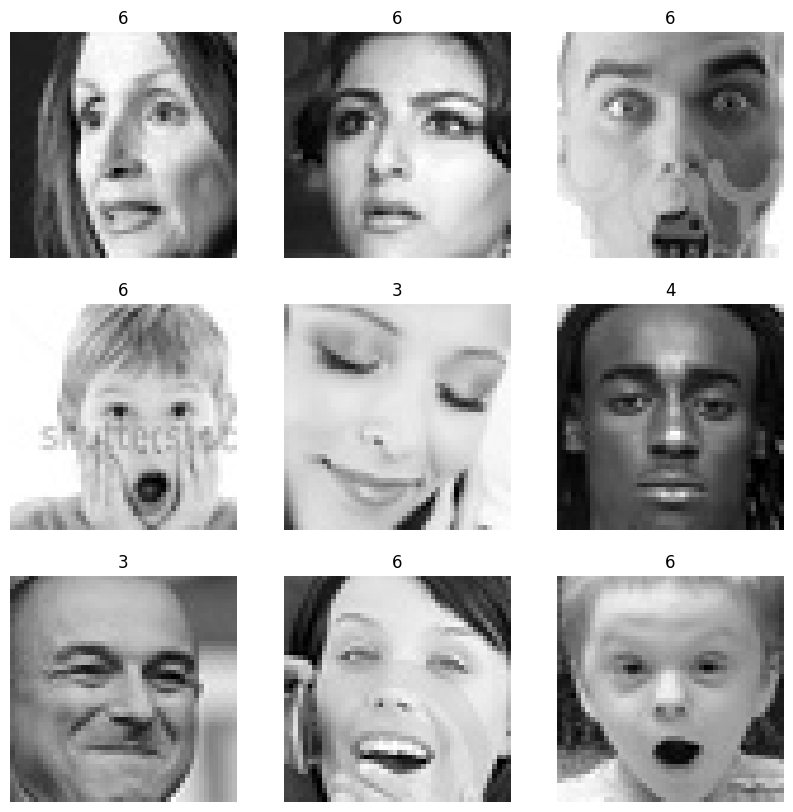

In [ ]:
from google.colab import files
uploaded = files.upload()
!unzip FER2013.zip -d FER2013
!ls FER2013
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/content/FER2013/train"
test_path  = "/content/FER2013/test"

# Validation split will be taken from train folder
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

img_size = (48, 48)
batch_size = 64

train_data = datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    subset='validation',
    shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)
train_data.class_indices
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].reshape(48,48), cmap='gray')
    plt.title(np.argmax(labels[i]))
    plt.axis('off')

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0266404434114071), 1: np.float64(9.401555464592715), 2: np.float64(1.0009587727708533), 3: np.float64(0.5684585684585685), 4: np.float64(0.826068191627104), 5: np.float64(0.8491570541259982), 6: np.float64(1.2933160650937552)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout
)


In [ ]:
cnn_model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    class_weight=class_weights
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 121s 327ms/step - accuracy: 0.1642 - loss: 2.8812 - val_accuracy: 0.2529 - val_loss: 2.6761
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 115s 322ms/step - accuracy: 0.1460 - loss: 1.9668 - val_accuracy: 0.2670 - val_loss: 1.9021
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 119s 332ms/step - accuracy: 0.1720 - loss: 1.9433 - val_accuracy: 0.2602 - val_loss: 1.8676
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 115s 320ms/step - accuracy: 0.1963 - loss: 1.8994 - val_accuracy: 0.2712 - val_loss: 1.8632
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 114s 319ms/step - accuracy: 0.2103 - loss: 1.8765 - val_accuracy: 0.3041 - val_loss: 1.8044
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 115s 320ms/step - accuracy: 0.2483 - loss: 1.8541 - val_accuracy: 0.2986 - val_loss: 1.7974
Epoch 7/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 115s 319ms/step - accuracy: 0.2589 - loss: 1.8401 - val_accuracy: 0.3207 - val_loss: 1.7792
Epoch 8/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 115s 319ms/step - accuracy: 0.2784 - los

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_data)
print("Custom CNN Test Accuracy:", cnn_acc)


  1/113 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - accuracy: 0.6250 - loss: 1.0814

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.5288 - loss: 1.2599
Custom CNN Test Accuracy: 0.5557258129119873


In [ ]:
cnn_model.save("custom_cnn_fer2013.keras")
from google.colab import files
files.download("custom_cnn_fer2013.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

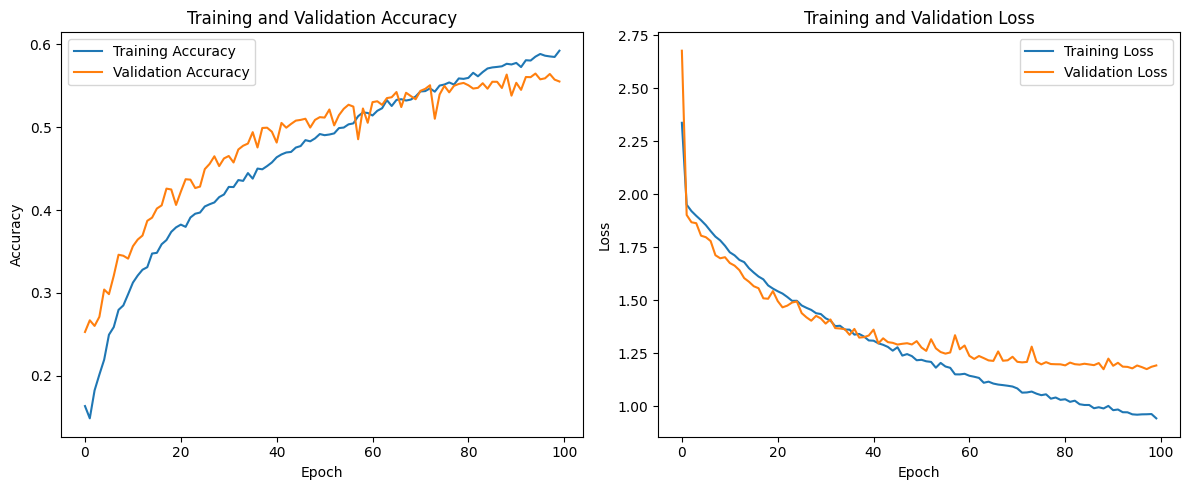

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred_probs = cnn_model.predict(test_data)
print("Shape of predicted probabilities:", y_pred_probs.shape)

113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step
Shape of predicted probabilities: (7178, 7)


In [ ]:
y_true = test_data.classes
print("Shape of true labels:", y_true.shape)

Shape of true labels: (7178,)


In [ ]:
import numpy as np
y_pred = np.argmax(y_pred_probs, axis=1)
print("Shape of predicted labels:", y_pred.shape)
print("First 10 predicted labels:", y_pred[:10])

Shape of predicted labels: (7178,)
First 10 predicted labels: [0 5 5 0 0 2 0 0 5 0]


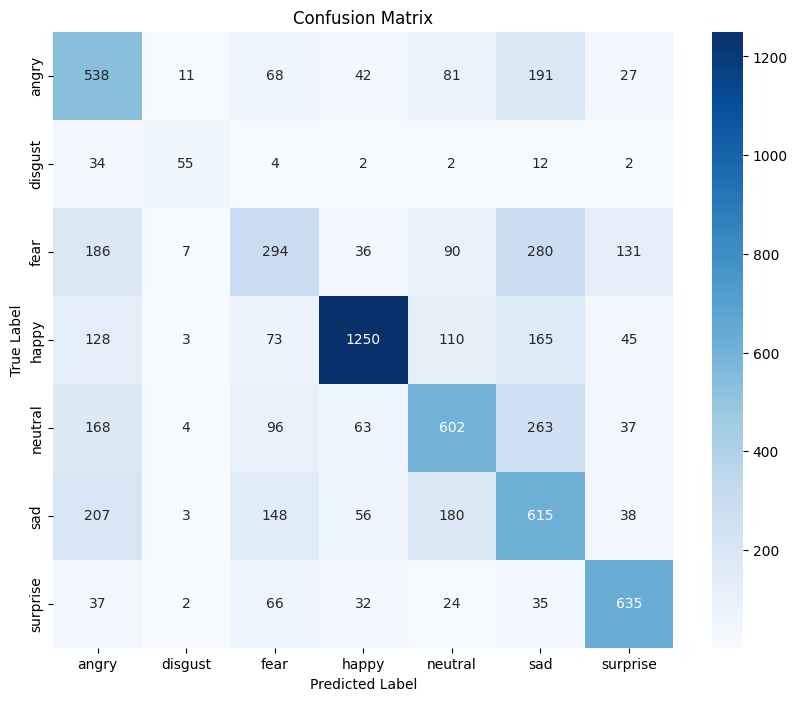

Classification Report:
               precision    recall  f1-score   support

       angry       0.41      0.56      0.48       958
     disgust       0.65      0.50      0.56       111
        fear       0.39      0.29      0.33      1024
       happy       0.84      0.70      0.77      1774
     neutral       0.55      0.49      0.52      1233
         sad       0.39      0.49      0.44      1247
    surprise       0.69      0.76      0.73       831

    accuracy                           0.56      7178
   macro avg       0.56      0.54      0.55      7178
weighted avg       0.57      0.56      0.56      7178



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get class names from the data generator
class_names = list(test_data.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Compute and display classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)